In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import diffusers
from PIL import Image




def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)



Matplotlib is building the font cache; this may take a moment.
/opt/anaconda3/envs/diffusion/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]An error occurred while trying to fetch /Users/johnkatsikis/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/johnkatsikis/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
100%|██████████| 1000/1000 [00:39<00:00, 25.20it/s]


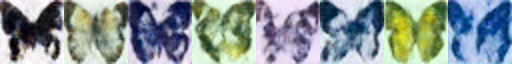

In [6]:
from diffusers import DDPMPipeline

butterfly_pipeline = DDPMPipeline.from_pretrained("johnowhitaker/ddpm-butterflies-32px").to(device)

images = butterfly_pipeline(batch_size=8).images

make_grid(images)

In [9]:
import torchvision

from datasets import load_dataset
from torchvision import transforms


dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

image_size = 32
batch_size = 64

preprocess = transforms.Compose(
    [

    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5]),
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

Repo card metadata block was not found. Setting CardData to empty.
Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 3095.41 examples/s]


X shape: torch.Size([8, 3, 32, 32])


/var/folders/lb/lmpvzmtd7wsch4zsvh_wcp1c0000gn/T/ipykernel_43341/2194200524.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


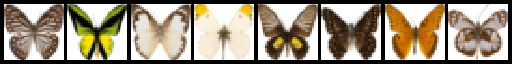

In [14]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 64, 64), resample = Image.NEAREST)

In [21]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

#noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.004)

#noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

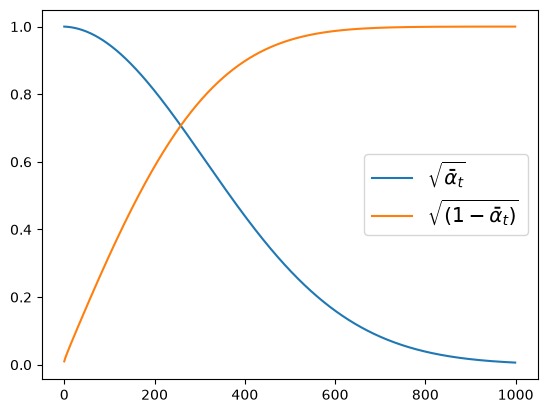

In [22]:
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");


Noisy X shape torch.Size([8, 3, 32, 32])


/var/folders/lb/lmpvzmtd7wsch4zsvh_wcp1c0000gn/T/ipykernel_43341/2194200524.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


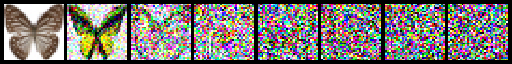

In [24]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 64, 64), resample = Image.NEAREST)

In [25]:
from diffusers import UNet2DModel


# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device);

In [26]:
with torch.no_grad():
    model_prediction = model(noisy_xb, timesteps).sample
model_prediction.shape

torch.Size([8, 3, 32, 32])

In [27]:
from tqdm.auto import tqdm  # .auto picks the notebook-friendly version in Jupyter, terminal version otherwise
import time

# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
losses = []
num_epochs = 30

# Outer bar: tracks epochs
epoch_bar = tqdm(range(num_epochs), desc="Training", unit="epoch")
for epoch in epoch_bar:
    epoch_start = time.time()
    epoch_losses = []

    # Inner bar: tracks steps within this epoch
    step_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch+1}/{num_epochs}",
        leave=False,          # inner bar disappears when the epoch finishes, keeping output clean
        unit="batch",
    )
    for step, batch in enumerate(step_bar):
        clean_images = batch["images"].to(device)

        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward()
        loss_value = loss.item()
        losses.append(loss_value)
        epoch_losses.append(loss_value)

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

        # Live loss on the step bar, updated every batch
        step_bar.set_postfix(loss=f"{loss_value:.4f}")

    # Per-epoch summary
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    epoch_time = time.time() - epoch_start

    # Show a running summary on the outer (epoch) bar
    epoch_bar.set_postfix(avg_loss=f"{avg_loss:.4f}", last=f"{losses[-1]:.4f}")

    # And print a persistent line so you have a scrollable history
    tqdm.write(
        f"Epoch {epoch+1:>2}/{num_epochs} | "
        f"avg loss: {avg_loss:.4f} | "
        f"last loss: {losses[-1]:.4f} | "
        f"min: {min(epoch_losses):.4f} | "
        f"time: {epoch_time:.1f}s"
    )

Training:   0%|          | 0/30 [00:00<?, ?epoch/s]/opt/anaconda3/envs/diffusion/lib/python3.12/site-packages/diffusers/configuration_utils.py:172: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
Training:   3%|▎         | 1/30 [00:18<08:44, 18.09s/epoch, avg_loss=0.4031, last=0.1798]

Epoch  1/30 | avg loss: 0.4031 | last loss: 0.1798 | min: 0.1798 | time: 18.1s


Training:   7%|▋         | 2/30 [00:25<05:34, 11.94s/epoch, avg_loss=0.1791, last=0.1757]

Epoch  2/30 | avg loss: 0.1791 | last loss: 0.1757 | min: 0.1363 | time: 7.6s


Training:  10%|█         | 3/30 [00:33<04:27,  9.91s/epoch, avg_loss=0.1602, last=0.1495]

...

Epoch 28/30 | avg loss: 0.0578 | last loss: 0.0630 | min: 0.0362 | time: 7.5s


Training:  97%|█████████▋| 29/30 [03:51<00:07,  7.64s/epoch, avg_loss=0.0573, last=0.0479]

Epoch 29/30 | avg loss: 0.0573 | last loss: 0.0479 | min: 0.0379 | time: 7.6s


Training: 100%|██████████| 30/30 [03:58<00:00,  7.96s/epoch, avg_loss=0.0649, last=0.0830]

Epoch 30/30 | avg loss: 0.0649 | last loss: 0.0830 | min: 0.0432 | time: 7.7s


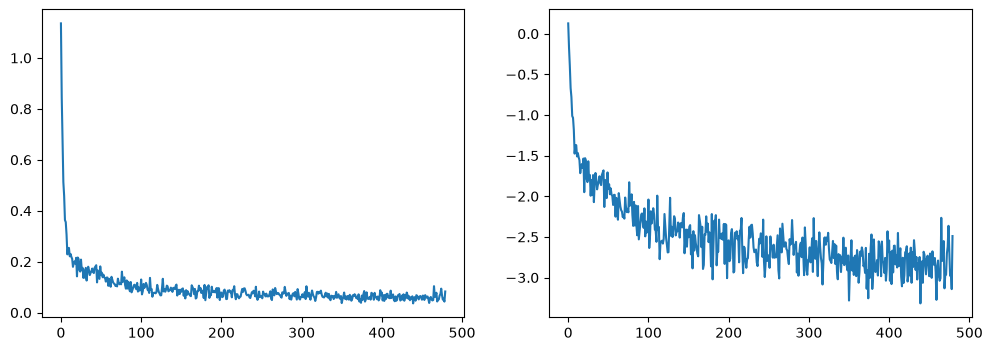

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

In [30]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)

100%|██████████| 1000/1000 [00:42<00:00, 23.77it/s]


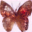

In [31]:
pipeline_output = image_pipe()
pipeline_output.images[0]

In [32]:
image_pipe.save_pretrained("my_pipeline")

/var/folders/lb/lmpvzmtd7wsch4zsvh_wcp1c0000gn/T/ipykernel_43341/2194200524.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


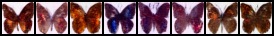

In [33]:
sample = torch.randn(8, 3, 32, 32).to(device)

for i, t in enumerate(noise_scheduler.timesteps):

    with torch.no_grad():
        residual = model(sample, t).sample

        sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample)